# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Hantavirus Detection Dataset**.


https://www.kaggle.com/datasets/tousifahamedrahat12/hantavirus-detection-dataset/data?select=hantavirus_detection_dataset.csv


# **2. Import Library**

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

In [67]:
df = pd.read_csv('/content/hantavirus_detection_dataset.csv')
df.head()

,Patient_ID,Age,Gender,Region,Hantavirus_Positive,Hantavirus_Type,Symptoms,Symptom_Count,Exposure_Type,Sample_Date,...,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL,Disease_Severity,WBC_Platelet_Ratio,Creatinine_BUN_Ratio,Liver_Injury_Score,Immunological_Risk,Renal_Risk
0,PATIENT_00001,69,M,Asia,0,NaN,NaN,0,Rodent Contact,2025-01-23,...,22.1,24.7,10.6,0.38,NaN,0.026,0.036,23.4,Low,Low
1,PATIENT_00002,76,M,Europe,0,NaN,"Fever, Fatigue",2,Unknown,2025-02-12,...,12.7,41.8,13.2,0.84,NaN,0.037,0.064,27.2,Low,Low
2,PATIENT_00003,61,M,South America,0,NaN,Asymptomatic,1,Rodent Contact,2024-06-10,...,14.3,38.1,20.6,1.05,NaN,0.039,0.051,26.2,Low,Low
3,PATIENT_00004,57,M,South America,0,NaN,"Dyspnea, Headache",2,Unknown,2025-12-25,...,29.3,30.0,5.5,0.74,NaN,0.020,0.135,29.7,Low,Low
4,PATIENT_00005,25,M,Asia,1,Seoul,Abdominal Pain,1,Unknown,2024-09-07,...,45.7,133.0,60.9,2.56,Severe,0.030,0.042,89.3,Low,High


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            10000 non-null  object 
 1   Age                   10000 non-null  int64  
 2   Gender                10000 non-null  object 
 3   Region                10000 non-null  object 
 4   Hantavirus_Positive   10000 non-null  int64  
 5   Hantavirus_Type       2571 non-null   object 
 6   Symptoms              7187 non-null   object 
 7   Symptom_Count         10000 non-null  int64  
 8   Exposure_Type         10000 non-null  object 
 9   Sample_Date           10000 non-null  object 
 10  Disease_Onset_Date    2571 non-null   object 
 11  WBC_Count_K/uL        10000 non-null  float64
 12  Platelet_Count_K/uL   10000 non-null  float64
 13  CRP_mg/L              10000 non-null  float64
 14  ALT_U/L               10000 non-null  float64
 15  AST_U/L             

In [69]:
df.describe()

,Age,Hantavirus_Positive,Symptom_Count,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL,WBC_Platelet_Ratio,Creatinine_BUN_Ratio,Liver_Injury_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.118600,0.257100,1.399600,7.172074,232.640248,15.499056,44.603360,50.282000,22.359360,1.205640,0.033298,0.068618,47.442730
std,19.360982,0.437057,1.296413,1.805691,52.370778,20.464505,32.415649,35.837208,12.302045,0.739308,0.016381,0.059178,30.065534
min,18.000000,0.000000,0.000000,2.000000,20.000000,0.100000,5.000000,5.000000,5.000000,0.300000,0.006000,0.004000,5.000000
25%,35.000000,0.000000,0.000000,6.000000,201.287500,3.740000,23.200000,26.200000,14.000000,0.800000,0.024000,0.037000,27.600000
50%,51.000000,0.000000,1.000000,7.130000,237.625000,6.345000,35.800000,41.000000,20.200000,0.970000,0.030000,0.052000,37.400000
75%,68.000000,1.000000,2.000000,8.280000,268.692500,12.335000,54.700000,62.000000,28.000000,1.220000,0.038000,0.079000,55.300000
max,84.000000,1.000000,5.000000,15.370000,403.400000,115.120000,190.100000,226.400000,90.300000,5.910000,0.488000,0.888000,197.700000


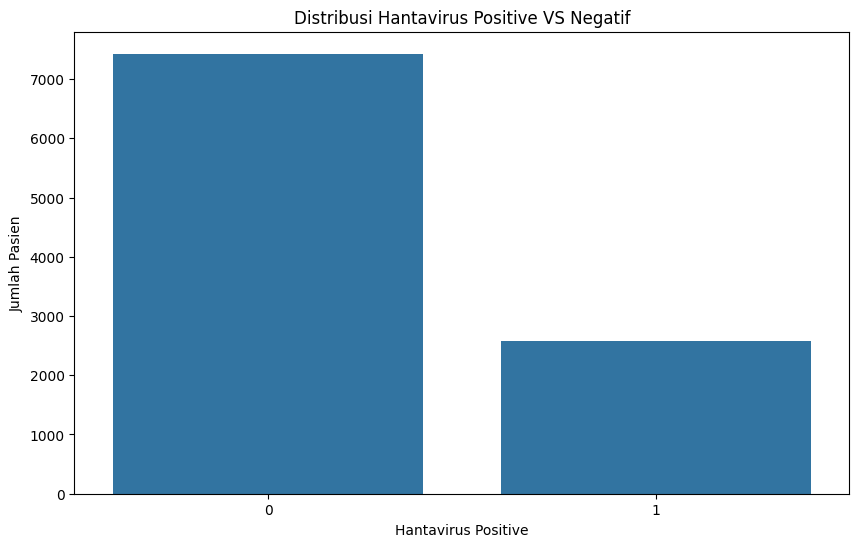

In [70]:
# Distribusi data
plt.figure(figsize=(10, 6))
sns.countplot(x='Hantavirus_Positive', data=df)
plt.title('Distribusi Hantavirus Positive VS Negatif')
plt.xlabel('Hantavirus Positive')
plt.ylabel('Jumlah Pasien')
plt.show()

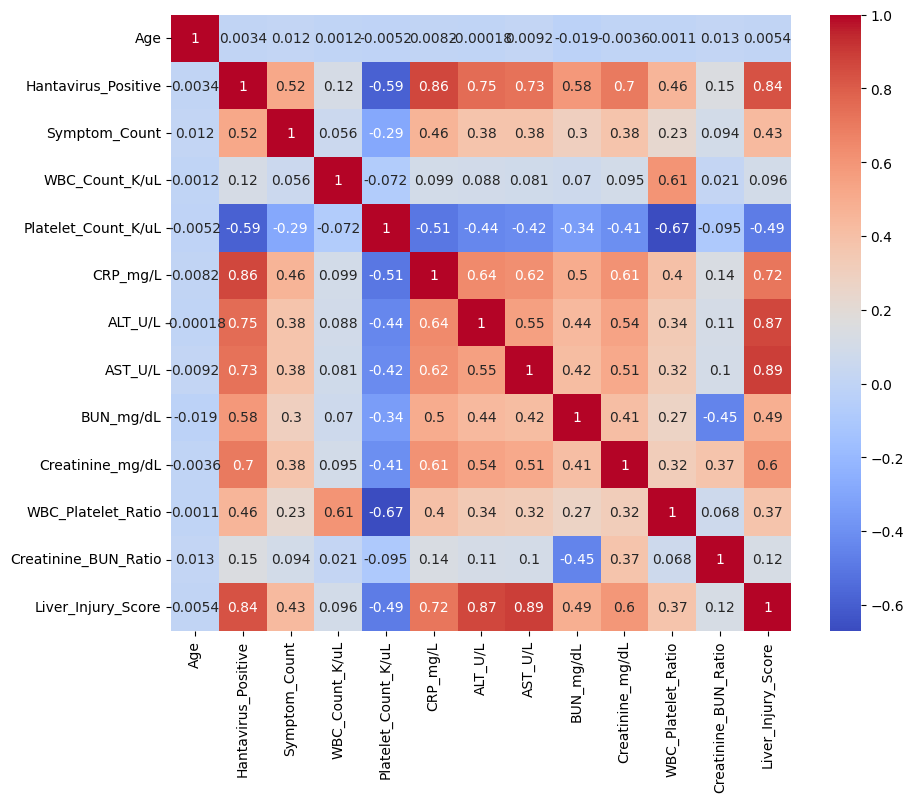

In [71]:
# correlation matrix untuk fitur numerik
col_numerik = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[col_numerik].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# **5. Data Preprocessing**

Menghapus atau Menangani Data Kosong (Missing Values)

In [72]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Region,0
Hantavirus_Positive,0
Hantavirus_Type,7429
Symptoms,2813
Symptom_Count,0
Exposure_Type,0
Sample_Date,0


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
# mengisi kolom 'Symptoms' dengan nilai 'No Symptoms' pada kolom yang kosong
df['Symptoms'] = df['Symptoms'].fillna('No Symptoms')

menghapus kolom yang tidak relevan

In [75]:
# menghapus kolom yang tidak relevan
df_clean = df.drop(columns=['Patient_ID', 'Sample_Date'])

# menghapus kolom 'Hantavirus_Type', 'Disease_Onset_Date', dan 'Disease_Severity' karena hanya muncul ketika hantavirus positif (1)
df_clean = df_clean.drop(columns=['Hantavirus_Type', 'Disease_Onset_Date', 'Disease_Severity'])

menghapus data duplikat

In [76]:
# menghapus data duplikat
df_clean = df_clean.drop_duplicates()

In [77]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  int64  
 1   Gender                10000 non-null  object 
 2   Region                10000 non-null  object 
 3   Hantavirus_Positive   10000 non-null  int64  
 4   Symptoms              10000 non-null  object 
 5   Symptom_Count         10000 non-null  int64  
 6   Exposure_Type         10000 non-null  object 
 7   WBC_Count_K/uL        10000 non-null  float64
 8   Platelet_Count_K/uL   10000 non-null  float64
 9   CRP_mg/L              10000 non-null  float64
 10  ALT_U/L               10000 non-null  float64
 11  AST_U/L               10000 non-null  float64
 12  BUN_mg/dL             10000 non-null  float64
 13  Creatinine_mg/dL      10000 non-null  float64
 14  WBC_Platelet_Ratio    10000 non-null  float64
 15  Creatinine_BUN_Ratio

melakukan label encoding pada data kategorikal

In [78]:
# encoding data kategorikal
data_categorical = df_clean.select_dtypes(include=['object'])
le = LabelEncoder()
df_clean[data_categorical.columns] = data_categorical.apply(le.fit_transform)

In [79]:
df_clean.head()

,Age,Gender,Region,Hantavirus_Positive,Symptoms,Symptom_Count,Exposure_Type,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL,WBC_Platelet_Ratio,Creatinine_BUN_Ratio,Liver_Injury_Score,Immunological_Risk,Renal_Risk
0,69,1,0,0,1128,0,4,7.42,290.42,3.26,22.1,24.7,10.6,0.38,0.026,0.036,23.4,1,1
1,76,1,1,0,775,2,5,8.43,228.22,5.33,12.7,41.8,13.2,0.84,0.037,0.064,27.2,1,1
2,61,1,3,0,141,1,4,7.48,194.26,0.10,14.3,38.1,20.6,1.05,0.039,0.051,26.2,1,1
3,57,1,3,0,527,2,5,4.25,216.26,3.46,29.3,30.0,5.5,0.74,0.020,0.135,29.7,1,1
4,25,1,0,1,0,1,5,5.26,174.40,74.38,45.7,133.0,60.9,2.56,0.030,0.042,89.3,1,0


split dataset menjadi data training dan data test

In [80]:
# memisahkan fitur dan target
X = df_clean.drop(columns=['Hantavirus_Positive'])
y = df_clean['Hantavirus_Positive']

In [81]:
X.head()

,Age,Gender,Region,Symptoms,Symptom_Count,Exposure_Type,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL,WBC_Platelet_Ratio,Creatinine_BUN_Ratio,Liver_Injury_Score,Immunological_Risk,Renal_Risk
0,69,1,0,1128,0,4,7.42,290.42,3.26,22.1,24.7,10.6,0.38,0.026,0.036,23.4,1,1
1,76,1,1,775,2,5,8.43,228.22,5.33,12.7,41.8,13.2,0.84,0.037,0.064,27.2,1,1
2,61,1,3,141,1,4,7.48,194.26,0.10,14.3,38.1,20.6,1.05,0.039,0.051,26.2,1,1
3,57,1,3,527,2,5,4.25,216.26,3.46,29.3,30.0,5.5,0.74,0.020,0.135,29.7,1,1
4,25,1,0,0,1,5,5.26,174.40,74.38,45.7,133.0,60.9,2.56,0.030,0.042,89.3,1,0


In [82]:
y.head()

,Hantavirus_Positive
0,0
1,0
2,0
3,0
4,1


In [83]:
# split dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

melakukan normalisasi data

In [84]:
# normalisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dalam preprocessing ini tidak dilakukan penanganan outlier dan binning karena dataset pasien bersifat sensitif dan dikhawatirkan dapat menghilangkan informasi medis penting untuk mendeteksi hantavirus. selain itu data outlier pada dataset ini tidak dihilangkan karena merupakan salah satu pola penting untuk mendeteksi pasien positif atau tidak.